# PRODUCE ALL RESULTS TOGETHER

C:\Users\20235062\AppData\Local\Temp\ipykernel_12096\785659497.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdYlBu_r')  # reversed so low stress = blue



Processing folder: 0_001
  Using 90 runs for folder 0_001
  Excluded 0 runs due to stress deviation.

Processing folder: 0_003
  Using 90 runs for folder 0_003
  Excluded 0 runs due to stress deviation.

Processing folder: 0_005
  Using 90 runs for folder 0_005
  Excluded 0 runs due to stress deviation.

Processing folder: 0_007
  Using 90 runs for folder 0_007
  Excluded 0 runs due to stress deviation.

Processing folder: 0_01
  Using 90 runs for folder 0_01
  Excluded 3 runs due to stress deviation.

Processing folder: 0_015
  Using 90 runs for folder 0_015
  Excluded 0 runs due to stress deviation.

Processing folder: 0_02
  Using 90 runs for folder 0_02
  Excluded 5 runs due to stress deviation.


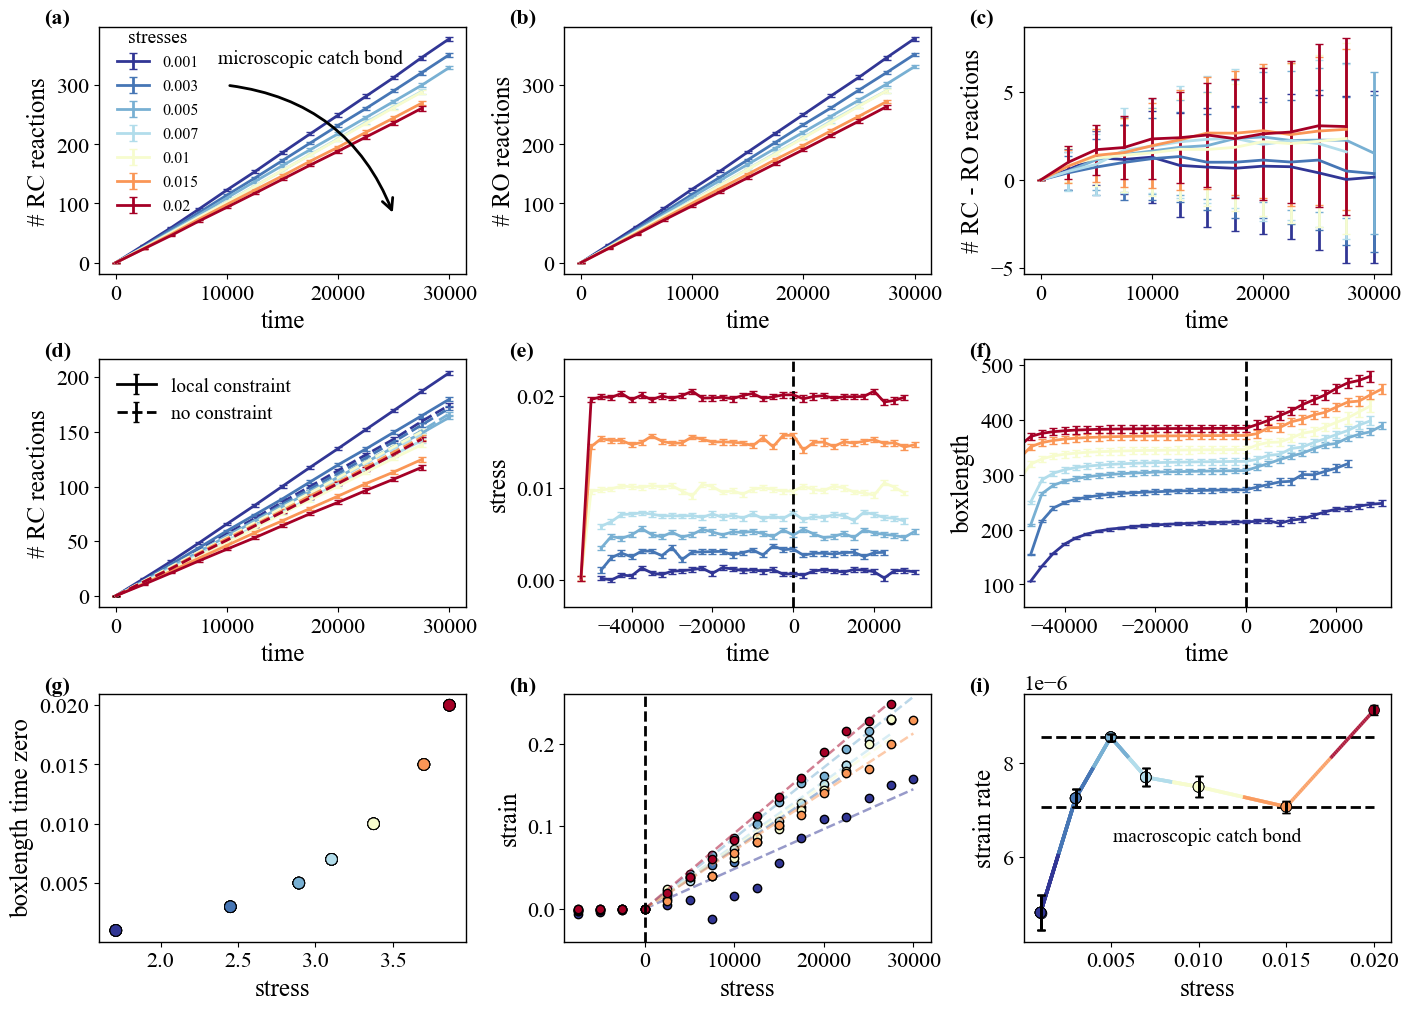

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.collections import LineCollection
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

# ----------------------------
# User settings
# ----------------------------
base_folders = ['0_001', '0_003', '0_005', '0_007', '0_01', '0_015', '0_02']
labels = ['0.001', '0.003', '0.005', '0.007', '0.01', '0.015', '0.02']

# Create perceptual color gradient
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize, to_hex
cmap = get_cmap('RdYlBu_r')  # reversed so low stress = blue
norm = Normalize(vmin=0.001, vmax=0.02)
colors = [to_hex(cmap(norm(float(l)))) for l in labels]

# Shift indices for alignment as not all target stresses had the same initial time
shift_indices = {
    '0_001': 19,
    '0_003': 19,
    '0_005': 19,
    '0_007': 19,
    '0_01': 21,
    '0_015': 21,
    '0_02': 21
}

# Time parameters
timestep = 0.0005
save_interval = 5_000_000
dt = timestep * save_interval  # 2500.0
digit_search = re.compile(r'(\d+)')

# Stress filter settings
target_stress = {
    '0_001': 0.001,
    '0_003': 0.003,
    '0_005': 0.005,
    '0_007': 0.007,
    '0_01': 0.01,
    '0_015': 0.015,
    '0_02': 0.02
}
stress_tolerance = 0.02
time_threshold = -40000

# ----------------------------
# Initialize storage
# ----------------------------
all_breaking_means, all_breaking_stderrs = [], []
all_on_chain_means, all_on_chain_stderrs = [], []
all_off_chain_means, all_off_chain_stderrs = [], []
all_forming_means, all_forming_stderrs = [], []
all_diff_means, all_diff_stderrs = [], []
all_pressure_means, all_pressure_stderrs = [], []
all_Lx_means, all_Lx_stderrs = [], []
all_time_points = []
included_labels, included_colors = [], []

# ================================================================
#                      DATA LOADING LOOP
# ================================================================
for base_folder, label, color in zip(base_folders, labels, colors):
    print(f"\nProcessing folder: {base_folder}")

    bond_folder = os.path.join(base_folder, 'bond_info_c7')
    pressure_folder = os.path.join(base_folder, 'pressure')

    if not os.path.isdir(bond_folder):
        print(f"  [Skip] No bond_info folder in {base_folder}")
        continue

    included_labels.append(label)
    included_colors.append(color)

    # ------------------------------------------------------------
    # Load bond_info data
    # ------------------------------------------------------------
    bond_files = sorted([f for f in os.listdir(bond_folder)
                         if f.startswith('bond_info.reacter') and f.endswith('.txt')])
    all_run_data = []

    for file_name in bond_files:
        file_path = os.path.join(bond_folder, file_name)
        try:
            with open(file_path, 'r') as f:
                lines = f.readlines()
        except Exception:
            continue

        data_lines = [l.strip() for l in lines if l.strip() and l.strip()[0].isdigit()]
        if not data_lines:
            continue

        start_idx = next((i for i, l in enumerate(data_lines)
                          if any(int(x) != 0 for x in l.split()[:3])), 0)
        data_lines = data_lines[start_idx:]
        if not data_lines:
            continue

        on_chain, off_chain, forming, time = [], [], [], []
        for line in data_lines:
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                on = int(parts[0])
                off = int(parts[1])
                fo = int(parts[2])
                t = int(parts[3])
            except ValueError:
                continue
            on_chain.append(on)
            off_chain.append(off)
            forming.append(fo)
            time.append(t)

        if len(time) == 0:
            continue

        all_run_data.append({
            'file_name': file_name,
            'breaking': np.array(on_chain) + np.array(off_chain),
            'forming': np.array(forming),
            'on_chain': np.array(on_chain),
            'off_chain': np.array(off_chain),
            'length': len(on_chain)
        })

    if not all_run_data:
        print(f"  [Skip] No usable bond_info runs")
        continue

    all_run_data.sort(key=lambda x: x['length'], reverse=True)
    top_runs = all_run_data[:90]
    min_len_bond = min(r['length'] for r in top_runs)
    print(f"  Using {len(top_runs)} runs for folder {base_folder}")

    def compute_mean_std(arrays):
        arr = np.array(arrays)
        mean = np.mean(arr, axis=0)
        stderr = np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]) if len(arrays) > 1 else np.zeros_like(mean)
        return mean, stderr

    breaking_sets = [r['breaking'][:min_len_bond] for r in top_runs]
    forming_sets = [r['forming'][:min_len_bond] for r in top_runs]
    on_chain_sets = [r['on_chain'][:min_len_bond] for r in top_runs]
    off_chain_sets = [r['off_chain'][:min_len_bond] for r in top_runs]

    bm, bse = compute_mean_std(breaking_sets)
    fm, fse = compute_mean_std(forming_sets)
    om, ose = compute_mean_std(on_chain_sets)
    ofm, ofse = compute_mean_std(off_chain_sets)

    bm = np.insert(bm, 0, 0); bse = np.insert(bse, 0, 0)
    fm = np.insert(fm, 0, 0); fse = np.insert(fse, 0, 0)
    om = np.insert(om, 0, 0); ose = np.insert(ose, 0, 0)
    ofm = np.insert(ofm, 0, 0); ofse = np.insert(ofse, 0, 0)

    dm = fm - bm
    dse = np.sqrt(fse**2 + bse**2)

    t = np.arange(len(bm)) * dt

    all_breaking_means.append(bm)
    all_breaking_stderrs.append(bse)
    all_forming_means.append(fm)
    all_forming_stderrs.append(fse)
    all_on_chain_means.append(om)
    all_on_chain_stderrs.append(ose)
    all_off_chain_means.append(ofm)
    all_off_chain_stderrs.append(ofse)
    all_diff_means.append(dm)
    all_diff_stderrs.append(dse)
    all_time_points.append(t)

    # ------------------------------------------------------------
    # Load pressure / Lx data with filtering
    # ------------------------------------------------------------
    pressure_sets, Lx_sets = [], []
    excluded_runs = 0

    pressure_files = sorted(
        [f for f in os.listdir(pressure_folder) if f.endswith('.csv')]
    ) if os.path.isdir(pressure_folder) else []

    for r in top_runs:
        idxs = digit_search.findall(r['file_name'])
        if not idxs:
            continue

        idx = idxs[0]
        match_pf = [pf for pf in pressure_files if re.search(rf'{idx}\D*\.csv$', pf)]
        if not match_pf:
            continue

        pf_path = os.path.join(pressure_folder, match_pf[0])

        try:
            arr = np.loadtxt(pf_path, delimiter=',')
            if arr.ndim == 1:
                arr = arr.reshape(1, -1)
            if arr.shape[1] >= 2:
                pressure = arr[:, 0].flatten()
                Lx = arr[:, 1].flatten()

                stress = -1 * pressure
                time_arr = (np.arange(len(stress)) - shift_indices[base_folder]) * dt

                mask_after = time_arr >= time_threshold
                stress_after = stress[mask_after]

                target = target_stress[base_folder]
                if np.any((stress_after < target - stress_tolerance) |
                          (stress_after > target + stress_tolerance)):
                    excluded_runs += 1
                    continue

                pressure_sets.append(pressure)
                Lx_sets.append(Lx)

        except Exception:
            continue

    print(f"  Excluded {excluded_runs} runs due to stress deviation.")

    def compute_mean_std_variable_length(arrays):
        if not arrays:
            return None, None
        min_len = min(len(a) for a in arrays)
        arr = np.array([a[:min_len] for a in arrays])
        mean = np.mean(arr, axis=0)
        stderr = np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(mean)
        return mean, stderr

    pm, pse = compute_mean_std_variable_length(pressure_sets)
    Lxm, Lxse = compute_mean_std_variable_length(Lx_sets)
    all_pressure_means.append(pm)
    all_pressure_stderrs.append(pse)
    all_Lx_means.append(Lxm)
    all_Lx_stderrs.append(Lxse)

# ================================================================
#                          PLOTTING
# ================================================================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "text.usetex": False,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
    "errorbar.capsize": 2.5,
    "axes.linewidth": 1.0,
})

import matplotlib as mpl

mpl.rcParams.update({
    "axes.labelsize": 18,      # x and y labels
    "axes.titlesize": 18,      # panel titles
    "xtick.labelsize": 16,     # x-axis tick numbers
    "ytick.labelsize": 16,     # y-axis tick numbers
    "legend.fontsize": 14,     # legend text
    "lines.linewidth": 2,
    "lines.markersize": 6,
})


fig, axs = plt.subplots(3, 3, figsize=(14, 10), constrained_layout=True)
axs = axs.reshape(3, 3)

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

slope_stresses = []
slope_values = []
slope_colors = []
slope_stderrs = []  # NEW

# ================================================================
# MAIN PLOTTING LOOP
# ================================================================
for i, lab in enumerate(included_labels):
    t = all_time_points[i]
    bm, bse = all_breaking_means[i], all_breaking_stderrs[i]
    fm, fse = all_forming_means[i], all_forming_stderrs[i]
    dm, dse = all_diff_means[i], all_diff_stderrs[i]
    om, ose = all_on_chain_means[i], all_on_chain_stderrs[i]
    ofm, ofse = all_off_chain_means[i], all_off_chain_stderrs[i]
    pm, pse = all_pressure_means[i], all_pressure_stderrs[i]
    Lxm, Lxse = all_Lx_means[i], all_Lx_stderrs[i]
    col = colors[i]
    shift_idx = shift_indices[base_folders[i]]

    # -------------------- Panels (a)-(f) --------------------
    axs[0,0].errorbar(t, bm, yerr=bse, fmt='-', capsize=3, label=lab, color=col)
    axs[0,1].errorbar(t, fm, yerr=fse, fmt='-', capsize=3, label=lab, color=col)
    axs[0,2].errorbar(t, dm, yerr=dse, fmt='-', capsize=3, label=lab, color=col)
    axs[1,0].errorbar(t, om, yerr=ose, fmt='-', capsize=3, color=col)
    axs[1,0].errorbar(t, ofm, yerr=ofse, fmt='--', capsize=3, color=col)
    if pm is not None:
        pressure_time = (np.arange(len(pm)) - shift_idx) * dt
        stress = -1 * pm
        axs[1,1].errorbar(pressure_time, stress, yerr=pse, fmt='-', capsize=3, color=col)
    if Lxm is not None:
        Lx_time = (np.arange(len(Lxm)) - shift_idx) * dt
        axs[1,2].errorbar(Lx_time, Lxm, yerr=Lxse, fmt='-', capsize=3, color=col)


   # HERE COMES THE REAL PANEL G, with boxlength at time zero on y-axis vs target stress on x-axis     


# -------------------- Panel (g): normalized Lx deviation vs target stress --------------------
    ax_g = axs[2,0]
    
    # Collect normalized box length deviation at time zero
    Lx0_values = np.array([
        all_Lx_means[i][shift_indices[base_folders[i]]]
        for i in range(len(included_labels))
    ])
    x_vals = (Lx0_values - 79.0686) / 79.0686  # normalized deviation
    
    # Vertical axis: target stresses
    y_vals = np.array([target_stress[base_folders[i]] for i in range(len(included_labels))])
    
    # Sort by x (optional, for plotting line)
    sort_idx = np.argsort(x_vals)
    x_vals = x_vals[sort_idx]
    y_vals = y_vals[sort_idx]
    
    # Indices of interest (3rd and 6th points, 0-based)
    i_start, i_end = 2, 5
    
    
    # Scatter all points
    ax_g.scatter(x_vals, y_vals, s=70, color=colors, edgecolor='k', linewidth=0.7, zorder=3)
    
    # Update labels
    ax_g.set_xlabel("(Lx(0) - 79.0686)/79.0686")
    ax_g.set_ylabel("Target Stress")



    




   # -------------------- Panel (h): Strain with slope --------------------
    if Lxm is not None:
        Lx0 = Lxm[shift_idx] if shift_idx < len(Lxm) else Lxm[0]
        Lx_time = (np.arange(len(Lxm)) - shift_idx) * dt
        strain = Lxm / Lx0 - 1
        mask = Lx_time >= 0
        if np.count_nonzero(mask) >= 2:
            x_fit = Lx_time[mask]
            y_fit = strain[mask]
    
            # Linear fit through zero
            a = np.sum(x_fit * y_fit) / np.sum(x_fit**2)
    
            # Residuals
            residuals = y_fit - a * x_fit
            n_points = len(x_fit)
            slope_stderr = np.sqrt(np.sum(residuals**2) / ((n_points - 1) * np.sum(x_fit**2)))
    
            # --- Compute linearity R^2 ---
            ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
            ss_res = np.sum(residuals**2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0  # avoid divide by zero
    
            # --- Combined error: slope error scaled by linearity ---
            combined_error = slope_stderr / np.sqrt(r2) if r2 > 0 else slope_stderr * 10  # large if very nonlinear
    
            # Store values for panel (h)
            slope_stresses.append(float(lab))
            slope_values.append(a)
            slope_stderrs.append(combined_error)  # use combined error now
            slope_colors.append(col)
    
            # Plot faint linear fit
            axs[2,1].plot(x_fit, a * x_fit, '--', color=col, lw=1.8, alpha=0.5)
    
        # Plot raw strain dots
        axs[2,1].plot(Lx_time, strain, marker='o', linestyle='None', 
                      markerfacecolor=col, markeredgecolor='k', markersize=6, alpha=1.0, label=lab)

    # -------------------- Panel (i): Strain rate vs Stress --------------------
    ax_h = axs[2,2]
    x_data = np.array(slope_stresses)
    y_data = np.array(slope_values)
    y_err = np.array(slope_stderrs)
    colors_data = np.array(slope_colors)
    
    if len(x_data) >= 1:
        sort_idx = np.argsort(x_data)
        x_data = x_data[sort_idx]
        y_data = y_data[sort_idx]
        y_err = y_err[sort_idx]
        colors_data = colors_data[sort_idx]
        # Plot error bars
        ax_h.errorbar(x_data, y_data, yerr=y_err, fmt='none', color='k', capsize=3, zorder=3)

        if len(x_data) > 1:
            x_smooth = np.linspace(x_data.min(), x_data.max(), 500)
            y_smooth = np.interp(x_smooth, x_data, y_data)
            def get_segment_colors(xs, x_orig, colors_orig):
                return np.array([colors_orig[np.argmin(np.abs(x_orig - xi))] for xi in xs])
            points = np.array([x_smooth, y_smooth]).T.reshape(-1,1,2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            segment_colors = get_segment_colors(x_smooth[:-1], x_data, colors_data)
            lc = LineCollection(segments, colors=segment_colors, linewidths=2.5, zorder=1)
            ax_h.add_collection(lc)
            ax_h.scatter(x_data, y_data, s=60, color=colors_data, edgecolor='k', linewidth=0.6, zorder=2)
        else:
            ax_h.scatter(x_data, y_data, s=60, color=colors_data, edgecolor='k', linewidth=0.6, zorder=2)
    ax_h.set_xlabel("Stress")
    ax_h.set_ylabel("Strain rate dε/dt")


# ================================================================
#                 PANEL TITLES AND AXIS LABELS
# ================================================================
titles = [
    "Breaking Reactions (Total)",              # (a)
    "Forming Reactions",                       # (b)
    "Forming $-$ Breaking",                    # (c)
    "On-chain (solid) + Off-chain (dashed)",   # (d)
    "Stress ($-P$)",                           # (e)
    "Box Length $L_x$",                        # (f)
    "Normalized Box Length $L_x/L_x(0)$",      # (g)
    "Panel (h) Title",                         # (h)
    "Panel (i) Title"                          # (i)
]

ylabels = [
    "# RC reactions", "# RO reactions", "# RC - RO reactions",
    "# RC reactions", "stress", "boxlength",
    "boxlength time zero", "strain", "strain rate"
]

for ax, title, ylabel, label in zip(axs.flat, titles, ylabels, panel_labels):
    ax.set_ylabel(ylabel)
    
    # Correct x-labels for panels h and i
    if label in ['(g)', '(h)', '(i)']:
        ax.set_xlabel("stress")
    else:
        ax.set_xlabel("time")
    
    ax.text(-0.15, 1.07, label, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')
    
    for spine in ax.spines.values():
        spine.set_visible(True)



# ------------------------------------------------------------
# Legends
# ------------------------------------------------------------
axs[0,0].legend(title="stresses", frameon=False, loc='upper left', bbox_to_anchor=(0.01, 1.05), fontsize=11.5, title_fontsize=14)



# Custom on/off legend in (d)
dummy_y = [0]; dummy_err = [0.1]
on_handle = axs[1,0].errorbar([0], dummy_y, yerr=dummy_err, fmt='-',
                              color='k', label='local constraint')
off_handle = axs[1,0].errorbar([0], dummy_y, yerr=dummy_err, fmt='--',
                               color='k', label='no constraint')
axs[1,0].legend(handles=[on_handle, off_handle], frameon=False, loc='best')


# ------------------------------------------------------------
# Axis limits
# ------------------------------------------------------------
axs[0,0].set_ylim(-20, 399)
axs[0,1].set_ylim(-20, 399)
axs[1,1].set_ylim(-0.003, 0.024)
axs[1,2].set_xlim(-49000, 32000)
axs[2,1].set_xlim(-9000, 32000)
axs[2,1].set_ylim(-0.04, 0.26)
axs[1,1].axvline(x=0, color='k', linestyle='--')
axs[1,2].axvline(x=0, color='k', linestyle='--')
axs[2,1].axvline(x=0, color='k', linestyle='--')




# ------------------------------------------------------------
# Add angled arrow + text in panel (a)
# ------------------------------------------------------------

import matplotlib.patches as patches

axA = axs[0,0]  # panel (a)

x_start, y_start = 10000, 300
x_end, y_end = 25000, 80

# Add a curved arrow using FancyArrowPatch
arrow = patches.FancyArrowPatch(
    (x_start, y_start),
    (x_end, y_end),
    connectionstyle="arc3,rad=-0.3",  # positive rad = bow upward
    arrowstyle='->',
    mutation_scale=20,
    color='black',
    lw=2,
    zorder=10  # draw on top
)
axA.add_patch(arrow)

# Compute midpoint of the curve for horizontal text
mid_x = (x_start + x_end)/2
mid_y = (y_start + y_end)/2 + 140  # offset above the curve

axA.text(
    mid_x, mid_y,
    "microscopic catch bond",
    fontsize=14,
    ha='center',
    va='bottom'
)

##### two dotted lines in panel h
ax_h = axs[2,2]

# Sort slopes by stress just in case
sort_idx = np.argsort(slope_stresses)
x_data = np.array(slope_stresses)[sort_idx]
y_data = np.array(slope_values)[sort_idx]

# Indices: 3rd and 6th points (0-based)
i_start, i_end = 2, 5

# Draw horizontal lines in the background
ax_h.hlines(
    y=y_data[i_start], xmin=x_data.min(), xmax=x_data.max(),
    colors='black', linestyles='--', linewidth=2, zorder=0
)
ax_h.hlines(
    y=y_data[i_end], xmin=x_data.min(), xmax=x_data.max(),
    colors='black', linestyles='--', linewidth=2, zorder=0
)

# Add label below the second line (6th stress)
x_mid = 0.5 * (x_data.min() + x_data.max())
y_label = y_data[i_end] - 0.1 * (y_data.max() - y_data.min())  # offset slightly below line

ax_h.text(
    x_mid, y_label,
    "macroscopic catch bond",
    fontsize=14,
    color='black',
    ha='center',
    va='top',
    alpha=1,
    zorder=1
)





import matplotlib as mpl
#mpl.rcParams['xtick.labelsize'] = 21  # x-axis ticks
#mpl.rcParams['ytick.labelsize'] = 21  # y-axis ticks
#mpl.rcParams['axes.labelsize'] = 17   # x and y axis labels


# Save
fig.savefig("reaction_analysis23.svg", format="svg", dpi=300)
plt.show()


# ONLY FIGURE 4

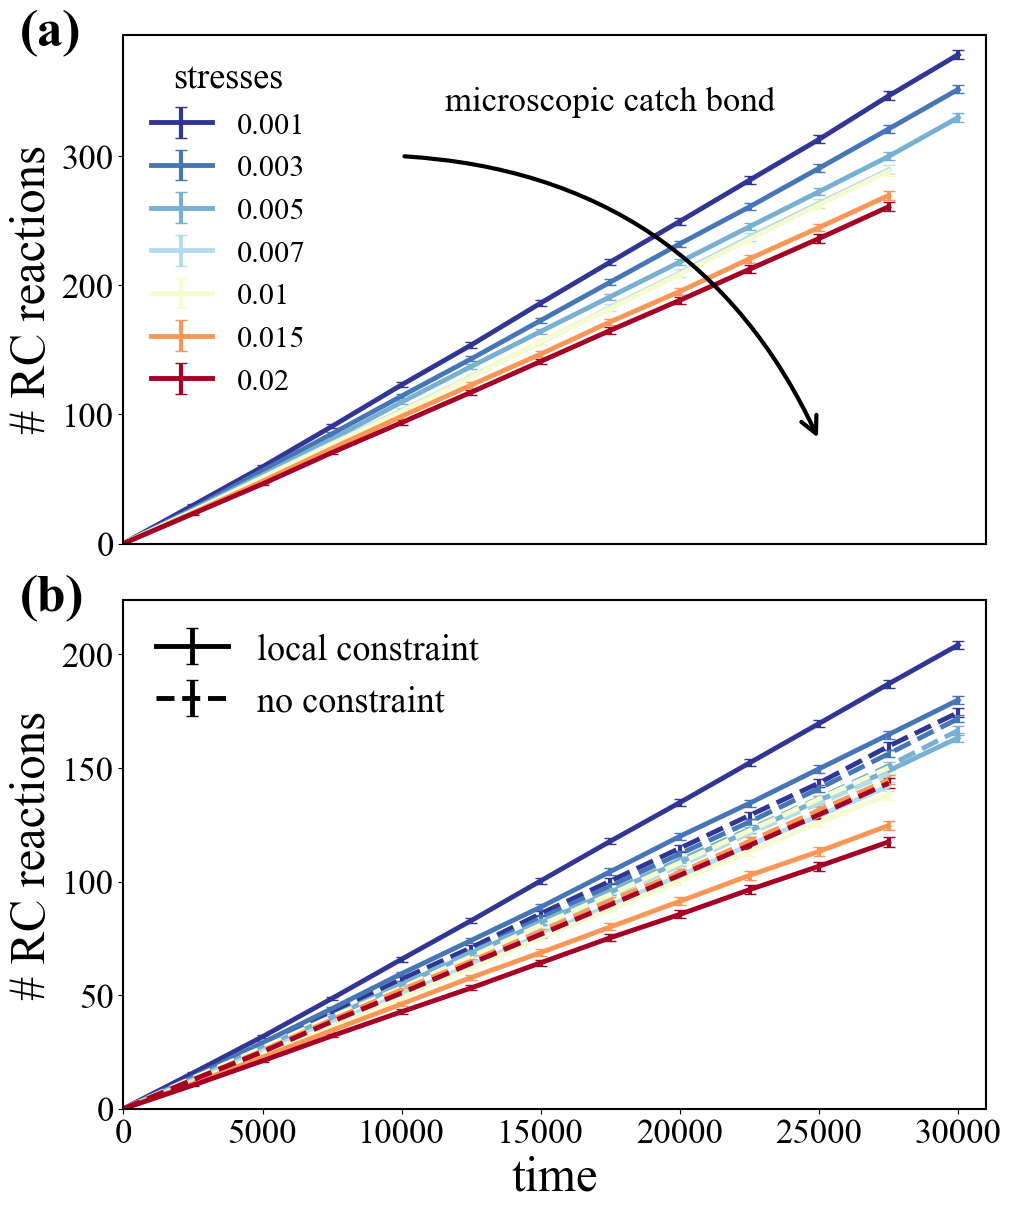

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl

# ----------------------------
# Publication-ready style (slightly bigger fonts)
# ----------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "text.usetex": False,
    "axes.labelsize": 35,        # bigger than before
    "axes.titlesize": 24,
    "legend.fontsize": 25,       # slightly bigger
    "lines.linewidth": 3.5,
    "lines.markersize": 10,
    "errorbar.capsize": 4,
    "axes.linewidth": 1.5,
})

# ----------------------------
# Figure setup: 2 rows, 1 column
# ----------------------------
fig, axs = plt.subplots(2, 1, figsize=(10, 12), constrained_layout=True)
axA, axB = axs

# -------------------- Panel (a) TOP: Breaking Reactions --------------------
for i, lab in enumerate(included_labels):
    t = all_time_points[i]
    bm, bse = all_breaking_means[i], all_breaking_stderrs[i]
    col = colors[i]
    axA.errorbar(
        t, bm, yerr=bse, fmt='-', lw=3.5, elinewidth=3, capsize=4,
        color=col, label=lab
    )

# Curved arrow + label
x_start, y_start = 10000, 300
x_end, y_end = 25000, 80
arrow = patches.FancyArrowPatch(
    (x_start, y_start),
    (x_end, y_end),
    connectionstyle="arc3,rad=-0.3",
    arrowstyle='->',
    mutation_scale=30,  # slightly bigger arrow
    color='black',
    lw=3,
    zorder=10
)
axA.add_patch(arrow)
mid_x = (x_start + x_end)/2
mid_y = (y_start + y_end)/2 + 140
axA.text(mid_x, mid_y, "microscopic catch bond", fontsize=25, ha='center', va='bottom')

# Panel label
axA.text(-0.12, 1.05, "(a)", transform=axA.transAxes, fontsize=38, fontweight='bold', va='top', ha='left')

# Axis labels and limits
axA.set_ylabel("# RC reactions")
axA.set_ylim(0, 394)
axA.set_xlim(0, 31000)

# Remove x-axis ticks and label
axA.set_xticks([])
axA.set_xlabel("")

# Legend
axA.legend(title="stresses", frameon=False, loc='upper left',
           fontsize=22, title_fontsize=26)

axA.tick_params(labelsize=25)
for spine in axA.spines.values():
    spine.set_visible(True)

# -------------------- Panel (b) BOTTOM: On-chain + Off-chain --------------------
for i, lab in enumerate(included_labels):
    t = all_time_points[i]
    om, ose = all_on_chain_means[i], all_on_chain_stderrs[i]
    ofm, ofse = all_off_chain_means[i], all_off_chain_stderrs[i]
    col = colors[i]
    axB.errorbar(t, om, yerr=ose, fmt='-', lw=3.5, elinewidth=3, capsize=4, color=col)
    axB.errorbar(t, ofm, yerr=ofse, fmt='--', lw=3.5, elinewidth=3, capsize=4, color=col)

# Custom on/off legend
dummy_y = [0]; dummy_err = [0.1]
on_handle = axB.errorbar([0], dummy_y, yerr=dummy_err, fmt='-', color='k', label='local constraint')
off_handle = axB.errorbar([0], dummy_y, yerr=dummy_err, fmt='--', color='k', label='no constraint')
axB.legend(handles=[on_handle, off_handle], frameon=False, loc='best', fontsize=26)

# Panel label
axB.text(-0.12, 1.05, "(b)", transform=axB.transAxes, fontsize=38, fontweight='bold', va='top', ha='left')

axB.set_ylabel("# RC reactions")
axB.set_xlabel("time")
axB.set_ylim(0, 224)
axB.set_xlim(0, 31000)
axB.tick_params(labelsize=25)
for spine in axB.spines.values():
    spine.set_visible(True)

# ----------------------------
# Save figure
# ----------------------------
fig.savefig("panels_a_b_vertical_bigger_font_noxtop.svg", format="svg", dpi=300)
plt.show()


# ONLY FIGURE 5

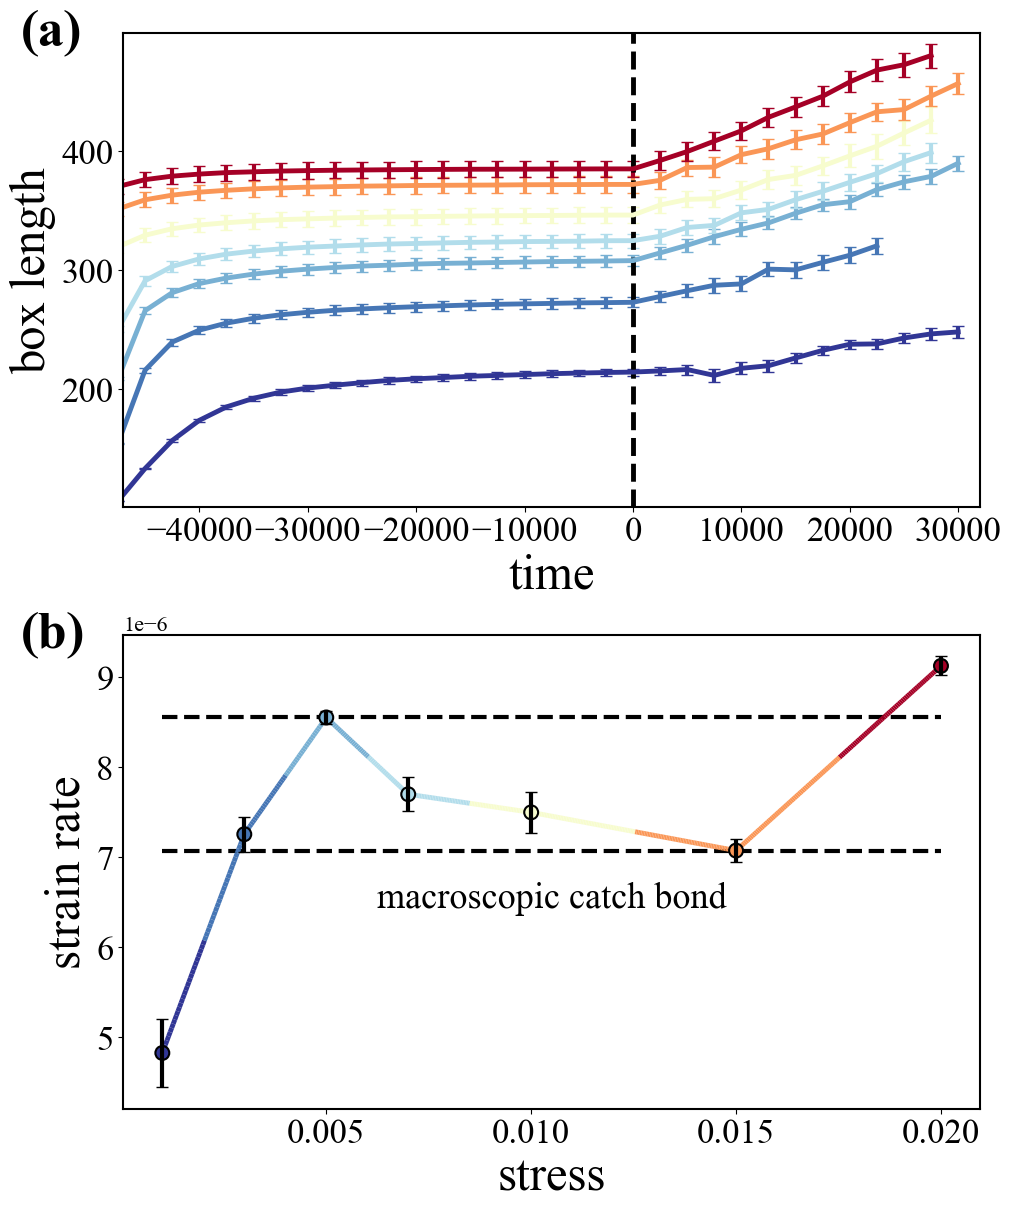

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
from matplotlib.collections import LineCollection
import numpy as np

# ----------------------------
# Publication-ready style (slightly bigger fonts)
# ----------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "text.usetex": False,
    "axes.labelsize": 35,
    "axes.titlesize": 24,
    "legend.fontsize": 25,
    "lines.linewidth": 3.5,
    "lines.markersize": 10,
    "errorbar.capsize": 4,
    "axes.linewidth": 1.5,
})

# ----------------------------
# Figure setup: 2 rows, 1 column
# ----------------------------
fig, axs = plt.subplots(2, 1, figsize=(10, 12), constrained_layout=True)
ax_box, ax_slope = axs

# -----------------------------
# Panel (a) TOP: Box length Lx(t)
# -----------------------------
for i, label in enumerate(included_labels):
    Lxm = all_Lx_means[i]
    Lxse = all_Lx_stderrs[i]
    col = colors[i]
    shift_idx = shift_indices[base_folders[i]]

    if Lxm is None or len(Lxm) == 0:
        continue

    # Proper time array for Lx
    Lx_time = (np.arange(len(Lxm)) - shift_idx) * dt

    ax_box.errorbar(Lx_time, Lxm,
                    yerr=Lxse if Lxse is not None else None,
                    fmt='-', lw=3.5, elinewidth=3, capsize=4,
                    color=col, label=label)

# Panel label
ax_box.text(-0.12, 1.05, "(a)", transform=ax_box.transAxes,
            fontsize=38, fontweight='bold', va='top', ha='left')

ax_box.set_xlabel("time")
ax_box.set_ylabel("box length")
ax_box.axvline(x=0, color='k', linestyle='--')
#ax_box.legend(title="Stress", frameon=False, loc='upper left',
              #fontsize=22, title_fontsize=26)
ax_box.tick_params(labelsize=25)
for spine in ax_box.spines.values():
    spine.set_visible(True)

ax_box.set_ylim(101, 499)
ax_box.set_xlim(-47000, 32000)

# -----------------------------
# Panel (b) BOTTOM: Strain rate vs stress
# -----------------------------
x_data = np.array(slope_stresses)
y_data = np.array(slope_values)
y_err = np.array(slope_stderrs)
colors_data = np.array(slope_colors)

if len(x_data) > 0:
    sort_idx = np.argsort(x_data)
    x_data = x_data[sort_idx]
    y_data = y_data[sort_idx]
    y_err = y_err[sort_idx]
    colors_data = colors_data[sort_idx]

    # Error bars
    ax_slope.errorbar(x_data, y_data, yerr=y_err,
                      fmt='none', color='k', capsize=4, lw=3, zorder=3)

    # Smooth colored line
    if len(x_data) > 1:
        x_smooth = np.linspace(x_data.min(), x_data.max(), 500)
        y_smooth = np.interp(x_smooth, x_data, y_data)
        points = np.array([x_smooth, y_smooth]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        def get_segment_colors(xs, x_orig, colors_orig):
            return np.array([colors_orig[np.argmin(np.abs(x_orig - xi))] for xi in xs])

        segment_colors = get_segment_colors(x_smooth[:-1], x_data, colors_data)
        lc = LineCollection(segments, colors=segment_colors, linewidths=3.5, zorder=1)
        ax_slope.add_collection(lc)
        ax_slope.scatter(x_data, y_data, s=100, color=colors_data, edgecolor='k', linewidth=1.5, zorder=2)
    else:
        ax_slope.scatter(x_data, y_data, s=100, color=colors_data, edgecolor='k', linewidth=1.5, zorder=2)

    # Optional horizontal guide lines (elastic / macroscopic catch bond)
    if len(y_data) > 5:
        i_start, i_end = 2, 5
        ax_slope.hlines(y=y_data[i_start], xmin=x_data.min(), xmax=x_data.max(),
                        colors='black', linestyles='--', linewidth=3, zorder=0)
        ax_slope.hlines(y=y_data[i_end], xmin=x_data.min(), xmax=x_data.max(),
                        colors='black', linestyles='--', linewidth=3, zorder=0)
        x_mid = 0.5 * (x_data.min() + x_data.max())
        y_label = y_data[i_end] - 0.08 * (y_data.max() - y_data.min())
        ax_slope.text(x_mid, y_label, "macroscopic catch bond", fontsize=26,
                      color='black', ha='center', va='top', zorder=1)

ax_slope.set_xlabel("stress")
ax_slope.set_ylabel("strain rate")
#ax_slope.set_title("Slope of strain vs target stress", fontsize=28)
ax_slope.tick_params(labelsize=25)
for spine in ax_slope.spines.values():
    spine.set_visible(True)

# Panel label
ax_slope.text(-0.12, 1.05, "(b)", transform=ax_slope.transAxes,
              fontsize=38, fontweight='bold', va='top', ha='left')



# ----------------------------
# Save figure
# ----------------------------
fig.savefig("boxlength_plus_strainrate_publication_style.svg", format="svg", dpi=300)
plt.show()


# OGDEN FIT SM

Ogden fit: mu = 0.0000 ± 0.0000, alpha = 6.0270 ± 0.2978


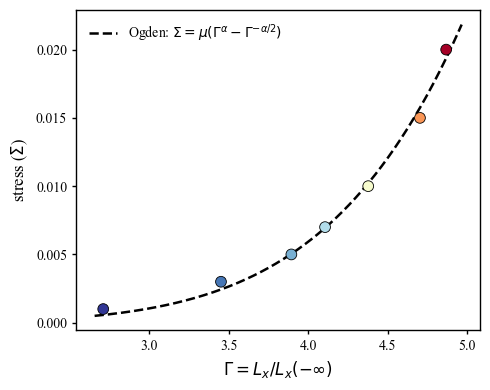

Stretch ratios (lambda): [2.7094677  3.45051107 3.8933866  4.10545634 4.37717744 4.70269895
 4.86771598]
True stress values: [0.001 0.003 0.005 0.007 0.01  0.015 0.02 ]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ------------------------------------------------------------
# Ogden model: 1-term
# ------------------------------------------------------------
def ogden_model(lmbda, mu, alpha):
    """1-term Ogden model: stress = mu*(lambda^alpha - lambda^(-alpha/2))"""
    return mu * (lmbda**alpha - lmbda**(-alpha/2))

Lx_ref = 79.0686  # normalization constant

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------
lambda_vals = []
stress_vals = []
colors_vals = []

for i, lab in enumerate(included_labels):
    Lxm = all_Lx_means[i]
    if Lxm is None:
        continue

    shift_idx = shift_indices[base_folders[i]]
    if shift_idx < len(Lxm):
        lam = Lxm[shift_idx] / Lx_ref
        lambda_vals.append(lam)
        stress_vals.append(float(lab))
        colors_vals.append(included_colors[i])

lambda_vals = np.array(lambda_vals)
stress_vals = np.array(stress_vals)

# ------------------------------------------------------------
# Fit Ogden model
# ------------------------------------------------------------
popt, pcov = curve_fit(
    ogden_model,
    lambda_vals,
    stress_vals,
    p0=[1.0, 2.0],
    bounds=([0, 0], [np.inf, np.inf])
)

mu_fit, alpha_fit = popt
mu_err, alpha_err = np.sqrt(np.diag(pcov))

print(f"Ogden fit: mu = {mu_fit:.4f} ± {mu_err:.4f}, alpha = {alpha_fit:.4f} ± {alpha_err:.4f}")

# ------------------------------------------------------------
# Plot data and fit
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4))

# Scatter data
ax.scatter(
    lambda_vals,
    stress_vals,
    s=60,                # slightly smaller points
    c=colors_vals,
    edgecolor='k',
    linewidth=0.6,
    zorder=3
)

# Fitted curve
lambda_fit = np.linspace(lambda_vals.min()*0.98, lambda_vals.max()*1.02, 400)
stress_fit = ogden_model(lambda_fit, mu_fit, alpha_fit)
ax.plot(lambda_fit, stress_fit, 'k--', lw=1.8,
        label=rf"Ogden: $\Sigma = \mu (\Gamma^\alpha - \Gamma^{{-\alpha/2}})$")

# ------------------------------------------------------------
# Formatting with smaller text
# ------------------------------------------------------------
ax.set_xlabel(r"$\Gamma = L_x / L_x(-\infty)$", fontsize=12)
ax.set_ylabel(r"stress ($\Sigma$)", fontsize=12)
ax.tick_params(direction='out', length=3, width=1, labelsize=10)
ax.legend(frameon=False, fontsize=10)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_visible(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
fig.savefig("ogden_fit_small_text.svg", format="svg", dpi=300)

# Optional: print data arrays
print("Stretch ratios (lambda):", lambda_vals)
print("True stress values:", stress_vals)
